# 02 · Fraud Feature Engineering

Turns cleaned transactions into model-ready features, documents what is **excluded** and why, and creates the train / validation / test splits.

All feature logic lives in [`src/feature_engineering.py`](../src/feature_engineering.py), so the API (Phase 8) computes features with exactly the same code. This notebook explains and checks that logic.

**Prerequisite:** `python -m src.preprocessing && python -m src.feature_engineering`

> All diagnostics use the **training split only**. Validation and test stay unseen until model selection and final evaluation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src import feature_engineering as fe
from src.preprocessing import load_clean_transactions

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_colwidth", 140)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold"})
# Categorical colours by feature group (validated colour-blind-safe order).
GROUP_COLORS = {"base": "#2a78d6", "origin": "#eb6834", "destination": "#1baf7a"}

## 1. Framing: post-transaction monitoring

The model scores a transaction **after it has been processed**, the way a monitoring team reviews completed payments. Post-transaction balances (`new_balance_*`) are therefore known at scoring time and are legitimate inputs.

The alternative is **real-time blocking** (scoring before approval), where post-transaction balances do not exist yet. Using them there would be leakage. The `no_origin_balance` feature set (section 4) is the closer approximation to that stricter setting.

## 2. Model scope: TRANSFER and CASH_OUT only

Notebook 01 found zero fraud in CASH_IN, DEBIT and PAYMENT. Training on them would add 3.59M trivially-easy negatives: accuracy and ROC-AUC would rise without the model learning anything new. Out-of-scope types will be handled by a rule in the API ("out of model scope").

In [2]:
clean = load_clean_transactions()
scoped = fe.filter_model_scope(clean)
print(f"Cleaned rows: {len(clean):,}  ->  in scope: {len(scoped):,} ({len(scoped) / len(clean):.1%})")
print(f"Fraud kept: {scoped['is_fraud'].sum():,} of {clean['is_fraud'].sum():,}")
print(f"Fraud rate in scope: {scoped['is_fraud'].mean():.4%} (vs {clean['is_fraud'].mean():.4%} overall)")
del clean

Cleaned rows: 6,362,604  ->  in scope: 2,770,393 (43.5%)
Fraud kept: 8,197 of 8,197
Fraud rate in scope: 0.2959% (vs 0.1288% overall)


## 3. Leakage review

### Columns excluded from every feature set

In [3]:
pd.DataFrame.from_dict(fe.EXCLUDED_COLUMNS, orient="index", columns=["reason"]).rename_axis("column")

,reason
column,
step,"Simulation artefact: legitimate traffic disappears in parts of the timeline (320 of 743 steps are 100% fraud), so the model would learn ..."
name_orig,Account identifier: 6.35M unique values; the model would memorise identities.
name_dest,Account identifier: memorisation risk; no mule-account concentration to exploit.
is_flagged_fraud,"Output of another fraud system (16 flags, all fraud), not an input signal."
transaction_id,"Row identifier; follows file order, which encodes the TRANSFER->CASH_OUT chain (cash-out is the next row in 4,075 fraud pairs)."
type,Replaced by the binary is_transfer (only two types are in scope).
amount,"Replaced by log_amount (same information, less skew)."


### Feature *ideas* rejected for leakage

| Idea | Why it is rejected |
|---|---|
| "Followed by a CASH_OUT of the same amount in the same step" | Uses a *future* row. When the TRANSFER is scored, the cash-out has not happened. (It also only works through file order: 0 of 4,272 chains are linked by account.) |
| Number of times an account appears in the dataset | Computed over the whole month, including transactions *after* the one being scored. A valid version would count prior activity only, and notebook 01b found no repeat victims or mule hubs to exploit. |
| Hour-of-day / day | Derived from `step`: the same simulation artefact. |
| `is_flagged_fraud` as a feature | It is another system's decision; the model should be compared *against* it, not fed by it. |

## 4. Engineered features
Each feature is computed from the transaction's own fields only, so one row can be scored on its own (as the API will do).

In [4]:
FEATURE_DOCS = {
    "log_amount": ("base", "log(1 + amount). Amounts span 0.01 to 92M; the log stops huge values dominating."),
    "is_transfer": ("base", "1 for TRANSFER, 0 for CASH_OUT. Fraud rate is ~4x higher for TRANSFER."),
    "log_old_balance_orig": ("origin", "log(1 + origin balance before)."),
    "log_new_balance_orig": ("origin", "log(1 + origin balance after)."),
    "orig_balance_error": ("origin", "signed log of (old - amount - new). 0 = ledger consistent; negative = amount exceeded the balance and it was floored at 0."),
    "log_amount_to_orig_balance": ("origin", "log(1+amount) - log(1+old balance). ~0 = whole balance moved; >0 = overspend; <0 = partial spend."),
    "orig_zero_before": ("origin", "Origin balance was 0 before the transaction."),
    "amount_exceeds_orig_balance": ("origin", "Amount larger than the available balance (legitimate overspend pattern)."),
    "orig_fully_drained": ("origin", "Amount equals the whole origin balance (> 0). The PaySim fraud artefact."),
    "log_old_balance_dest": ("destination", "log(1 + destination balance before)."),
    "log_new_balance_dest": ("destination", "log(1 + destination balance after)."),
    "dest_balance_error": ("destination", "signed log of (old + amount - new). Positive = money that never showed up at the destination."),
    "dest_zero_before_and_after": ("destination", "Destination shows 0 -> 0 despite receiving money."),
}
assert list(FEATURE_DOCS) == fe.FEATURE_SETS["full"]

feature_table = pd.DataFrame(
    [(name, group, desc, name in fe.FEATURE_SETS["no_origin_balance"]) for name, (group, desc) in FEATURE_DOCS.items()],
    columns=["feature", "group", "definition", "in no_origin_balance set"],
)
feature_table

,feature,group,definition,in no_origin_balance set
0,log_amount,base,log(1 + amount). Amounts span 0.01 to 92M; the log stops huge values dominating.,True
1,is_transfer,base,"1 for TRANSFER, 0 for CASH_OUT. Fraud rate is ~4x higher for TRANSFER.",True
2,log_old_balance_orig,origin,log(1 + origin balance before).,False
3,log_new_balance_orig,origin,log(1 + origin balance after).,False
4,orig_balance_error,origin,signed log of (old - amount - new). 0 = ledger consistent; negative = amount exceeded the balance and it was floored at 0.,False
5,log_amount_to_orig_balance,origin,log(1+amount) - log(1+old balance). ~0 = whole balance moved; >0 = overspend; <0 = partial spend.,False
6,orig_zero_before,origin,Origin balance was 0 before the transaction.,False
7,amount_exceeds_orig_balance,origin,Amount larger than the available balance (legitimate overspend pattern).,False
8,orig_fully_drained,origin,Amount equals the whole origin balance (> 0). The PaySim fraud artefact.,False
9,log_old_balance_dest,destination,log(1 + destination balance before).,True


### Two feature sets
| Set | Features | Purpose |
|---|---|---|
| `full` | all 13 | Best achievable on PaySim under post-transaction monitoring |
| `no_origin_balance` | 6 (base + destination) | Removes the origin-balance artefact, so we can see what a model learns beyond "the account was emptied" |

## 5. Train / validation / test split

| Choice | Reason | Alternative considered |
|---|---|---|
| **70 / 15 / 15** | Validation is used to pick thresholds and risk-level boundaries (Phase 5); test is used **once** for final metrics | 80/20 with thresholds tuned on test, which leaks test information into decisions |
| **Stratified** on `is_fraud` | At 0.3% fraud, a random split could leave one split short of fraud | Unstratified split |
| **Random**, not chronological | Legitimate traffic vanishes from day 18, so a time-based test set would be mostly fraud | Time-based split (the right choice for real data with stable traffic) |
| `random_state = 42` | Reproducible | |

In [5]:
splits = {name: pd.read_parquet(path) for name, path in fe.SPLIT_PATHS.items()}
display(fe.split_summary(splits))

ids = {name: set(part["transaction_id"]) for name, part in splits.items()}
print("Overlap train/validation:", len(ids["train"] & ids["validation"]),
      "| train/test:", len(ids["train"] & ids["test"]),
      "| validation/test:", len(ids["validation"] & ids["test"]))
print("Total rows across splits:", f"{sum(len(p) for p in splits.values()):,}", "(should equal in-scope rows above)")

,rows,fraud,fraud_rate_pct
train,1939275,5738,0.2959
validation,415559,1229,0.2957
test,415559,1230,0.2960


Overlap train/validation: 0 | train/test: 0 | validation/test: 0
Total rows across splits: 2,770,393 (should equal in-scope rows above)


## 6. Sanity checks (training split)

In [6]:
train = splits["train"]
X_train, y_train = train[fe.FEATURE_SETS["full"]], train["is_fraud"]
print("Non-finite values:", int((~np.isfinite(X_train.to_numpy(dtype=float))).sum()))
X_train.describe().T

Non-finite values: 0


,count,mean,std,min,25%,50%,75%,max
log_amount,"1,939,275.0000",11.9281,1.2322,0.0100,11.3265,12.0513,12.6340,18.3421
is_transfer,"1,939,275.0000",0.1923,0.3941,0.0000,0.0000,0.0000,0.0000,1.0000
log_old_balance_orig,"1,939,275.0000",5.2764,5.2049,0.0000,0.0000,5.7236,10.3416,17.9029
log_new_balance_orig,"1,939,275.0000",1.0929,3.3386,0.0000,0.0000,0.0000,0.0000,17.7192
orig_balance_error,"1,939,275.0000",-10.6854,3.7867,-18.3421,-12.5428,-11.8751,-10.8566,0.0100
log_amount_to_orig_balance,"1,939,275.0000",6.6517,5.3362,-12.7109,1.6106,6.3296,11.9624,18.3421
orig_zero_before,"1,939,275.0000",0.4722,0.4992,0.0000,0.0000,0.0000,1.0000,1.0000
amount_exceeds_orig_balance,"1,939,275.0000",0.8984,0.3021,0.0000,1.0000,1.0000,1.0000,1.0000
orig_fully_drained,"1,939,275.0000",0.0029,0.0538,0.0000,0.0000,0.0000,0.0000,1.0000
log_old_balance_dest,"1,939,275.0000",11.5625,4.9064,0.0000,11.7614,13.2279,14.3681,19.6905


## 7. How well does each feature separate fraud on its own?

**Single-feature ROC-AUC** on the training split: how well ranking transactions by that one feature puts fraud above legitimate. 0.5 = useless, 1.0 = perfect. "Separation" is `max(AUC, 1 − AUC)`, so features where *lower* means fraud are comparable. This is a diagnostic, not a model.

,feature,group,separation,direction,legit_mean,fraud_mean
0,orig_fully_drained,origin,0.9899,higher = fraud,0.0000,0.9798
1,amount_exceeds_orig_balance,origin,0.9487,lower = fraud,0.9011,0.0037
2,orig_balance_error,origin,0.9464,higher = fraud,-10.7169,-0.0763
3,log_old_balance_orig,origin,0.9269,higher = fraud,5.2539,12.8487
4,log_amount_to_orig_balance,origin,0.8991,lower = fraud,6.6713,0.0336
5,log_old_balance_dest,destination,0.7857,lower = fraud,11.5835,4.4841
6,dest_zero_before_and_after,destination,0.7472,higher = fraud,0.0006,0.4949
7,dest_balance_error,destination,0.7471,higher = fraud,-0.3360,6.3459
8,orig_zero_before,origin,0.7351,lower = fraud,0.4736,0.0035
9,log_new_balance_dest,destination,0.7271,lower = fraud,13.5585,6.9200


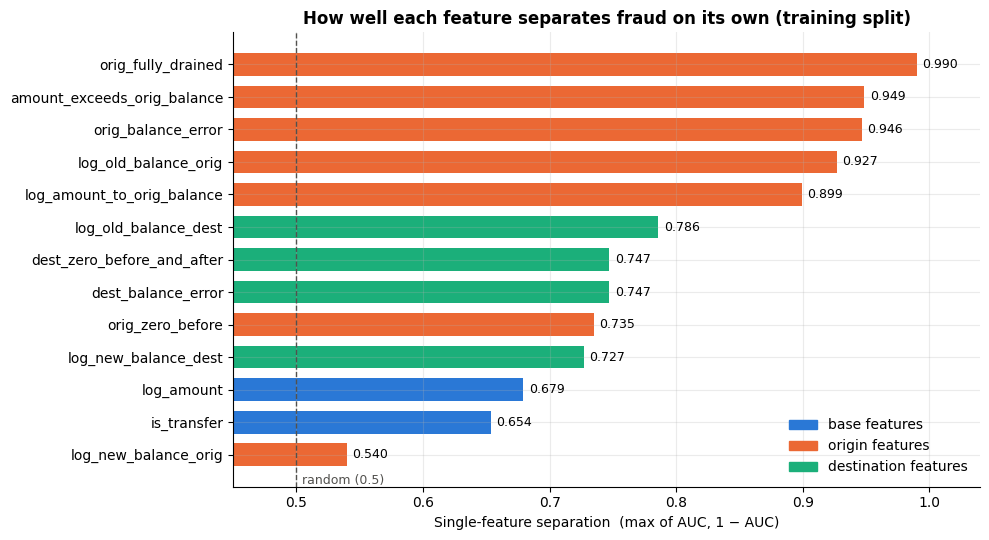

In [7]:
rows = []
for name in fe.FEATURE_SETS["full"]:
    auc = roc_auc_score(y_train, X_train[name])
    rows.append({
        "feature": name,
        "group": FEATURE_DOCS[name][0],
        "separation": max(auc, 1 - auc),
        "direction": "higher = fraud" if auc >= 0.5 else "lower = fraud",
        "legit_mean": X_train.loc[y_train == 0, name].mean(),
        "fraud_mean": X_train.loc[y_train == 1, name].mean(),
    })
univariate = pd.DataFrame(rows).sort_values("separation", ascending=False).reset_index(drop=True)
display(univariate)

plot = univariate.sort_values("separation")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(plot["feature"], plot["separation"], color=plot["group"].map(GROUP_COLORS), height=0.7)
ax.axvline(0.5, color="#52514e", linewidth=1, linestyle="--")
ax.annotate("random (0.5)", (0.5, -0.9), xytext=(4, 0), textcoords="offset points", fontsize=9, color="#52514e")
for y, v in enumerate(plot["separation"]):
    ax.annotate(f"{v:.3f}", (v, y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_xlim(0.45, 1.04)
ax.set_xlabel("Single-feature separation  (max of AUC, 1 − AUC)")
ax.set_title("How well each feature separates fraud on its own (training split)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in GROUP_COLORS.values()]
ax.legend(handles, [f"{g} features" for g in GROUP_COLORS], loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

> **Finding:**
> - **`orig_fully_drained` alone reaches 0.990**: 97.98% of training frauds have it vs ~0% of legitimate transactions. This is the simulator artefact again, now at feature level.
> - The top five features are all **origin-balance** features (0.899–0.990).
> - The **destination** features carry real but weaker signal (0.727–0.786). `dest_zero_before_and_after` is set for 49.49% of frauds vs 0.06% of legitimate transactions.
> - `log_amount` (0.679) and `is_transfer` (0.654) are modest on their own.
> - `log_new_balance_orig` is nearly uninformative (0.540), because legitimate *and* fraudulent transactions usually end at 0.
> - *Implication:* in the `no_origin_balance` set, no single feature exceeds **0.786**. Any model performance well above that comes from combining features, which is a meaningful test of the models in Phase 4.

## 8. Collinearity

In [8]:
corr = X_train.corr().abs()
pairs = [
    (a, b, corr.loc[a, b])
    for i, a in enumerate(corr.columns) for b in corr.columns[i + 1:]
    if corr.loc[a, b] > 0.8
]
pd.DataFrame(pairs, columns=["feature_a", "feature_b", "abs_correlation"]).sort_values("abs_correlation", ascending=False)

,feature_a,feature_b,abs_correlation
3,log_new_balance_orig,amount_exceeds_orig_balance,0.9735
0,log_old_balance_orig,log_amount_to_orig_balance,0.9730
1,log_old_balance_orig,orig_zero_before,0.9589
4,orig_balance_error,amount_exceeds_orig_balance,0.9488
5,log_amount_to_orig_balance,orig_zero_before,0.9338
2,log_new_balance_orig,orig_balance_error,0.9236


> **Finding:** Six pairs of **origin** features have |r| > 0.8 (up to 0.974, `log_new_balance_orig` ~ `amount_exceeds_orig_balance`). They describe the same balance behaviour in different forms.
> - **Tree models** (Random Forest, XGBoost) are not harmed by this.
> - **Logistic regression** predictions are fine, but individual coefficients become unstable and should not be read one at a time. Phase 4 will use L2 regularisation, and explanations will come from SHAP rather than raw coefficients.
> - We keep the correlated features rather than hand-pruning them: different models use different forms best, and SHAP will show which ones actually matter.

## Summary

- **Scope:** 2,770,393 TRANSFER/CASH_OUT transactions, 8,197 frauds (0.296%). Other types are out of scope.
- **13 features** in two sets: `full` (13) and `no_origin_balance` (6). Each one is computed from a single transaction, so it is identical in training and in the API.
- **Excluded:** `step`, account IDs, `is_flagged_fraud`, `transaction_id`, chain features, and whole-dataset account counts, each for a documented leakage or artefact reason.
- **Splits:** 70/15/15 stratified, with the fraud rate equal across splits (0.2957–0.2960%) and no overlap.

### Implications for Phase 4 (modelling)
1. Expect near-perfect scores with the `full` set. They must be reported next to the one-line drain rule (97.82% recall, 100% precision), or they will overstate what the model contributes.
2. The `no_origin_balance` set is the more informative comparison (best single feature 0.786).
3. Class imbalance is about 337:1 in scope, so we will use class weights (`class_weight`, `scale_pos_weight`) and choose thresholds on validation, rather than SMOTE.
4. Logistic regression gets scaled inputs and L2 regularisation because of the collinearity.